# Simulation Results Analysis

## Binary-Ta-NLP-Sector Simulation Results

In [142]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    _HAS_SEABORN = True
except Exception:
    _HAS_SEABORN = False

plt.style.use('seaborn-v0_8-whitegrid')


In [143]:
RESULTS_DIR = Path('../results/simulation/binary-ta-nlp-sector')
csv_paths = sorted(RESULTS_DIR.glob('*.csv'))
if not csv_paths:
    raise FileNotFoundError(f'No CSVs found in {RESULTS_DIR.resolve()}')

dfs = {}
for path in csv_paths:
    df = pd.read_csv(path)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')

    # Use filename stem as the primary label to avoid collisions
    mode = path.stem
    df['mode'] = mode
    dfs[mode] = df

list(dfs.keys())


['HYBRID_KELLY_MPT_H1_EE_OFF_no_meta',
 'HYBRID_KELLY_MPT_H1_EE_ON_no_meta',
 'HYBRID_KELLY_MPT_H5_EE_OFF_no_meta',
 'HYBRID_KELLY_MPT_H5_EE_ON_no_meta',
 'KELLY_ONLY_H1_EE_OFF_no_meta',
 'KELLY_ONLY_H1_EE_ON_no_meta',
 'KELLY_ONLY_H5_EE_OFF_no_meta',
 'KELLY_ONLY_H5_EE_ON_no_meta',
 'MPT_ONLY_H1_EE_OFF_no_meta',
 'MPT_ONLY_H1_EE_ON_no_meta',
 'MPT_ONLY_H5_EE_OFF_no_meta',
 'MPT_ONLY_H5_EE_ON_no_meta']

In [144]:
import re


def _parse_maybe(value):
    if isinstance(value, (list, dict)):
        return value
    if isinstance(value, float) and np.isnan(value):
        return None
    if isinstance(value, str):
        text = value.strip()
        text = re.sub(r"Timestamp\(\'([^']+)\'\)", r"'\1'", text)
        if text == '' or text.lower() == 'nan':
            return None
        if text[0] in '[{(' and text[-1] in ']})':
            try:
                return ast.literal_eval(text)
            except Exception:
                return None
    return value

def _ensure_returns(df):
    if 'daily_return' not in df.columns and {'equity_start', 'equity_end'}.issubset(df.columns):
        prev_end = df['equity_end'].shift(1).fillna(df['equity_start'])
        df['daily_return'] = (df['equity_start'] / prev_end) - 1.0
    return df

def _metrics_from_df(df, rf=0.0):
    df = df.copy()
    df = _ensure_returns(df)
    rets = df['daily_return'].astype(float).fillna(0.0).values
    if len(rets) == 0:
        return {}

    eq = df['equity_end'] if 'equity_end' in df.columns else None
    start_equity = df['equity_start'].iloc[0] if 'equity_start' in df.columns else np.nan
    end_equity = df['equity_end'].iloc[-1] if 'equity_end' in df.columns else np.nan

    total_return = (end_equity / start_equity - 1.0) if start_equity not in (0, np.nan) else np.nan
    n_days = len(rets)
    ann_factor = 252
    cagr = (1 + total_return) ** (ann_factor / n_days) - 1 if n_days > 0 and np.isfinite(total_return) else np.nan

    vol = np.std(rets, ddof=1) * np.sqrt(ann_factor) if n_days > 1 else np.nan
    mean_ret = np.mean(rets)
    sharpe = (mean_ret - rf / ann_factor) / (np.std(rets, ddof=1) + 1e-12) * np.sqrt(ann_factor) if n_days > 1 else np.nan

    downside = rets[rets < 0]
    sortino = (mean_ret - rf / ann_factor) / (np.std(downside, ddof=1) + 1e-12) * np.sqrt(ann_factor) if len(downside) > 1 else np.nan

    if eq is not None:
        roll_max = eq.cummax()
        drawdown = (eq / roll_max) - 1.0
        max_dd = drawdown.min() if len(drawdown) else np.nan
    else:
        max_dd = np.nan

    win_rate = float(np.mean(rets > 0)) if n_days else np.nan
    avg_win = np.mean(rets[rets > 0]) if np.any(rets > 0) else np.nan
    avg_loss = np.mean(rets[rets < 0]) if np.any(rets < 0) else np.nan
    profit_factor = -np.sum(rets[rets > 0]) / (np.sum(rets[rets < 0]) - 1e-12) if np.any(rets < 0) else np.nan

    return {
        'days': n_days,
        'start_equity': start_equity,
        'end_equity': end_equity,
        'total_return': total_return,
        'CAGR': cagr,
        'volatility': vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_drawdown': max_dd,
        'win_rate': win_rate,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'profit_factor': profit_factor,
    }


In [145]:
summary_rows = []
for mode, df in dfs.items():
    metrics = _metrics_from_df(df)
    metrics['mode'] = mode
    summary_rows.append(metrics)

summary_df = pd.DataFrame(summary_rows).set_index('mode').sort_values('total_return', ascending=False)
summary_df


,days,start_equity,end_equity,total_return,CAGR,volatility,sharpe,sortino,max_drawdown,win_rate,avg_win,avg_loss,profit_factor
mode,,,,,,,,,,,,,
MPT_ONLY_H5_EE_OFF_no_meta,109,100000.0,109162.755405,0.091628,0.224688,0.036989,5.500070,10.201666,-0.011364,0.522936,0.002406,-0.001405,2.789853
MPT_ONLY_H5_EE_ON_no_meta,109,100000.0,109162.755405,0.091628,0.224688,0.036989,5.500070,10.201666,-0.011364,0.522936,0.002406,-0.001405,2.789853
HYBRID_KELLY_MPT_H5_EE_OFF_no_meta,109,100000.0,107950.185834,0.079502,0.193466,0.028212,6.285184,9.280551,-0.011449,0.669725,0.001605,-0.001305,2.895964
HYBRID_KELLY_MPT_H5_EE_ON_no_meta,109,100000.0,107950.185834,0.079502,0.193466,0.028212,6.285184,9.280551,-0.011449,0.669725,0.001605,-0.001305,2.895964
KELLY_ONLY_H5_EE_OFF_no_meta,109,100000.0,103773.443370,0.037734,0.089407,0.019094,4.495150,8.223912,-0.008126,0.550459,0.001171,-0.000753,2.120111
KELLY_ONLY_H5_EE_ON_no_meta,109,100000.0,103773.443370,0.037734,0.089407,0.019094,4.495150,8.223912,-0.008126,0.550459,0.001171,-0.000753,2.120111
MPT_ONLY_H1_EE_OFF_no_meta,109,100000.0,102563.896801,0.025639,0.060275,0.034239,1.726539,2.721745,-0.010336,0.559633,0.001672,-0.001627,1.334481
MPT_ONLY_H1_EE_ON_no_meta,109,100000.0,102563.896801,0.025639,0.060275,0.034239,1.726539,2.721745,-0.010336,0.559633,0.001672,-0.001627,1.334481
HYBRID_KELLY_MPT_H1_EE_OFF_no_meta,109,100000.0,102265.783088,0.022658,0.053164,0.030511,1.713014,2.469046,-0.008354,0.559633,0.001438,-0.001386,1.347083


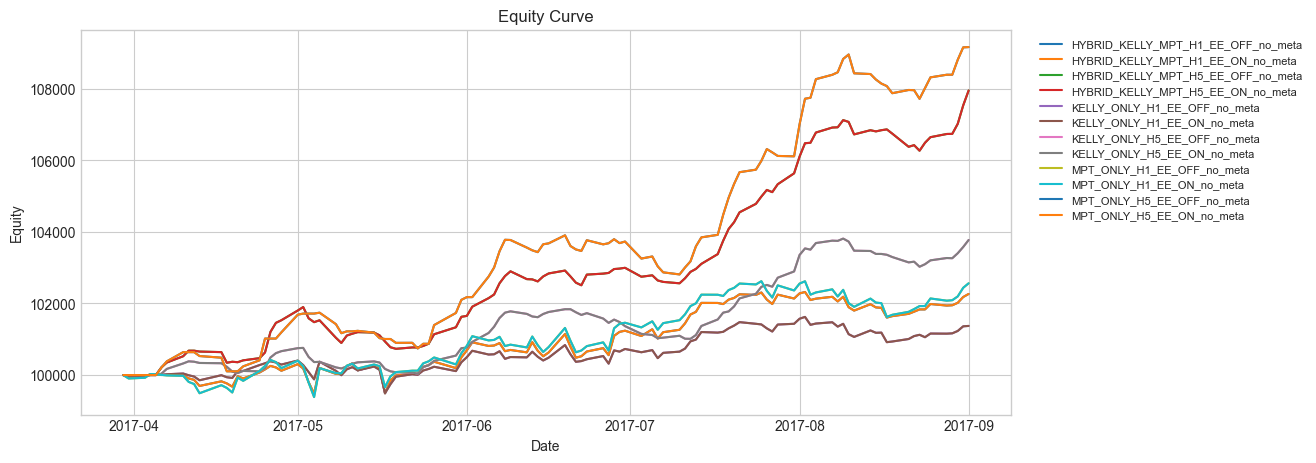

In [146]:
fig, ax = plt.subplots(figsize=(12, 5))
for mode, df in dfs.items():
    if 'equity_end' in df.columns:
        ax.plot(df['date'], df['equity_end'], label=mode)
ax.set_title('Equity Curve')
ax.set_xlabel('Date')
ax.set_ylabel('Equity')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


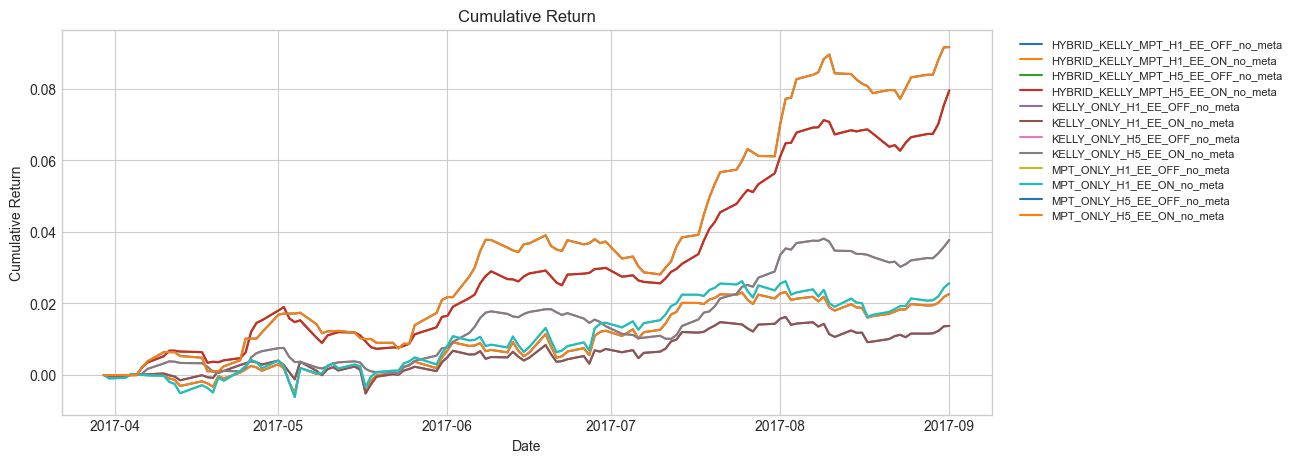

In [147]:
fig, ax = plt.subplots(figsize=(12, 5))
for mode, df in dfs.items():
    if 'equity_end' in df.columns and 'equity_start' in df.columns:
        base = df['equity_start'].iloc[0]
        ax.plot(df['date'], df['equity_end'] / base - 1.0, label=mode)
ax.set_title('Cumulative Return')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


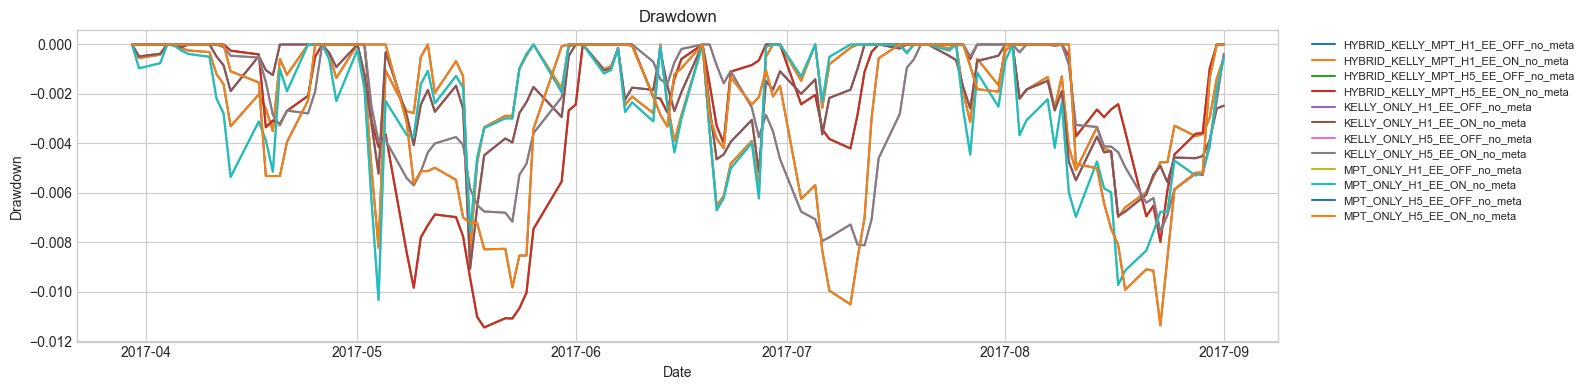

In [148]:
fig, ax = plt.subplots(figsize=(16, 4))
for mode, df in dfs.items():
    if 'equity_end' in df.columns:
        roll_max = df['equity_end'].cummax()
        drawdown = df['equity_end'] / roll_max - 1.0
        ax.plot(df['date'], drawdown, label=mode)
ax.set_title('Drawdown')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


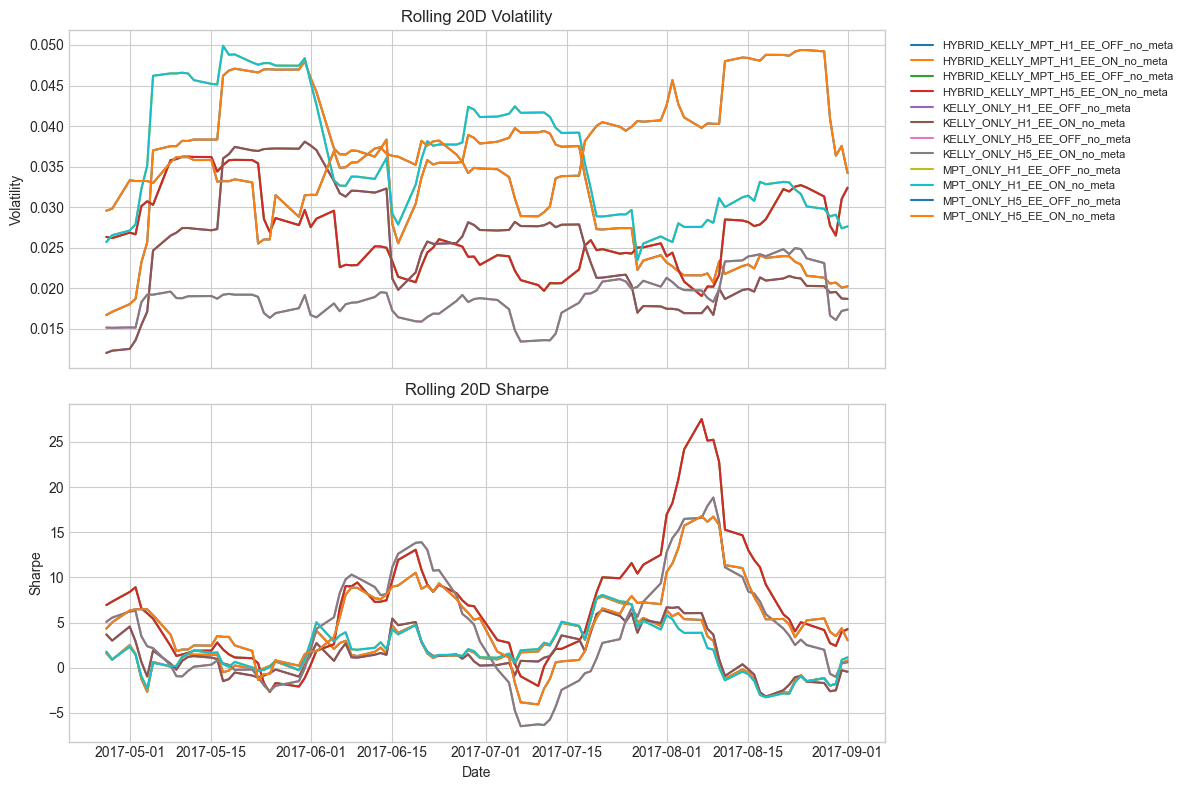

In [149]:
window = 20
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for mode, df in dfs.items():
    df = _ensure_returns(df)
    rets = df['daily_return'].astype(float).fillna(0.0)
    roll_vol = rets.rolling(window).std() * np.sqrt(252)
    roll_sharpe = rets.rolling(window).mean() / (rets.rolling(window).std() + 1e-12) * np.sqrt(252)
    axes[0].plot(df['date'], roll_vol, label=mode)
    axes[1].plot(df['date'], roll_sharpe, label=mode)

axes[0].set_title(f'Rolling {window}D Volatility')
axes[0].set_ylabel('Volatility')
axes[1].set_title(f'Rolling {window}D Sharpe')
axes[1].set_ylabel('Sharpe')
axes[1].set_xlabel('Date')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


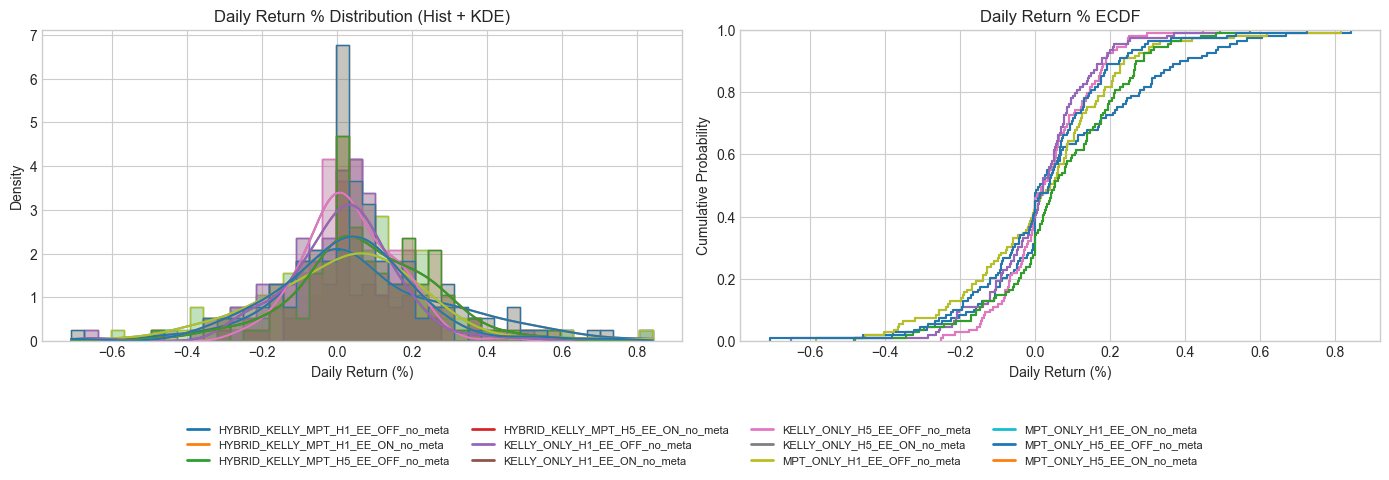

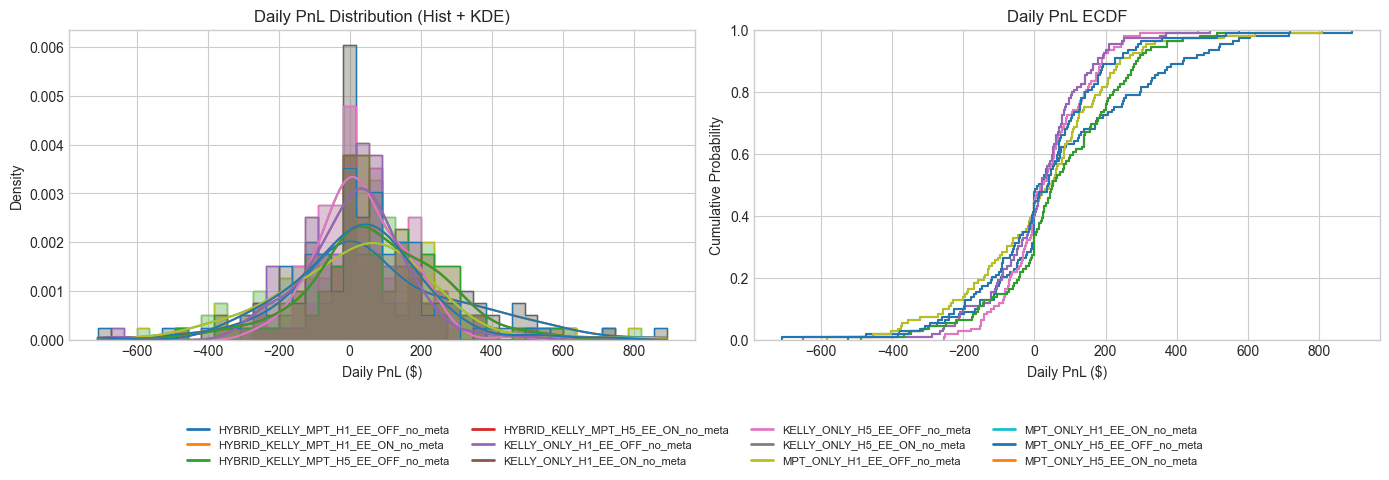

,max_abs_diff,mean_abs_diff,csv_nonnull,calc_nonnull
mode,,,,
HYBRID_KELLY_MPT_H1_EE_OFF_no_meta,6.514971e-16,1.373520e-16,109,109
HYBRID_KELLY_MPT_H1_EE_ON_no_meta,6.514971e-16,1.373520e-16,109,109
HYBRID_KELLY_MPT_H5_EE_OFF_no_meta,4.276093e-16,1.118229e-16,109,109
HYBRID_KELLY_MPT_H5_EE_ON_no_meta,4.276093e-16,1.118229e-16,109,109
KELLY_ONLY_H1_EE_OFF_no_meta,5.277896e-16,1.790026e-16,109,109
KELLY_ONLY_H1_EE_ON_no_meta,5.277896e-16,1.790026e-16,109,109
KELLY_ONLY_H5_EE_OFF_no_meta,5.208507e-16,1.279435e-16,109,109
KELLY_ONLY_H5_EE_ON_no_meta,5.208507e-16,1.279435e-16,109,109
MPT_ONLY_H1_EE_OFF_no_meta,5.397158e-16,1.412653e-16,109,109


In [150]:
def _calc_daily_return(df):
    df = df.copy()
    if 'equity_end' in df.columns:
        prev_end = df['equity_end'].shift(1)
        if 'equity_start' in df.columns:
            prev_end = prev_end.fillna(df['equity_start'])
        else:
            prev_end = prev_end.fillna(df['equity_end'])
        return (df['equity_end'] / prev_end) - 1.0
    if 'daily_pnl_realized' in df.columns and 'equity_start' in df.columns:
        prev_end = df['equity_start'].shift(1).fillna(df['equity_start'])
        return df['daily_pnl_realized'] / prev_end
    if 'daily_return' in df.columns:
        return df['daily_return'].astype(float)
    return pd.Series(np.nan, index=df.index)

all_returns = []
pnl_rows = []
diag_rows = []
for mode, df in dfs.items():
    df = df.copy()
    csv_returns = df['daily_return'].astype(float) if 'daily_return' in df.columns else pd.Series(np.nan, index=df.index)
    calc_returns = _calc_daily_return(df).astype(float)

    diff = (csv_returns - calc_returns).abs()
    diag_rows.append({
        'mode': mode,
        'max_abs_diff': diff.max(),
        'mean_abs_diff': diff.mean(),
        'csv_nonnull': csv_returns.notna().sum(),
        'calc_nonnull': calc_returns.notna().sum(),
    })

    all_returns.append(pd.DataFrame({'mode': mode, 'daily_return': calc_returns}))
    if 'daily_pnl_realized' in df.columns:
        pnl_rows.append(pd.DataFrame({'mode': mode, 'daily_pnl': df['daily_pnl_realized'].astype(float)}))

returns_df = pd.concat(all_returns, ignore_index=True)
returns_df = returns_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['daily_return'])
returns_df['daily_return_pct'] = returns_df['daily_return'] * 100.0

pnl_df = pd.concat(pnl_rows, ignore_index=True) if pnl_rows else pd.DataFrame(columns=['mode', 'daily_pnl'])
pnl_df = pnl_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['daily_pnl'])

# Build a color map that covers all modes present
mode_order = sorted(returns_df['mode'].unique())
if _HAS_SEABORN:
    palette = sns.color_palette('tab10', n_colors=max(len(mode_order), 1))
else:
    palette = plt.cm.tab10.colors if len(mode_order) <= 10 else plt.cm.tab20.colors
mode_color_map = {mode: palette[i % len(palette)] for i, mode in enumerate(mode_order)}

# -------------------- RETURNS FIGURE --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Returns: histogram + KDE
if _HAS_SEABORN:
    sns.histplot(data=returns_df, x='daily_return_pct', hue='mode', element='step', stat='density',
                 common_norm=False, kde=True, palette=mode_color_map, ax=axes[0], legend=False)
else:
    for mode in returns_df['mode'].unique():
        subset = returns_df[returns_df['mode'] == mode]['daily_return_pct']
        axes[0].hist(subset, bins=30, alpha=0.35, label=mode, density=True, color=mode_color_map.get(mode))
axes[0].set_title('Daily Return % Distribution (Hist + KDE)')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Density')

# Returns: ECDF
if _HAS_SEABORN:
    sns.ecdfplot(data=returns_df, x='daily_return_pct', hue='mode', palette=mode_color_map, ax=axes[1], legend=False)
else:
    for mode in returns_df['mode'].unique():
        subset = np.sort(returns_df[returns_df['mode'] == mode]['daily_return_pct'].values)
        y = np.arange(1, len(subset) + 1) / len(subset)
        axes[1].plot(subset, y, label=mode, color=mode_color_map.get(mode))
axes[1].set_title('Daily Return % ECDF')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Cumulative Probability')

# Shared legend below the returns plots
handles = [plt.Line2D([0], [0], color=mode_color_map[m], lw=2) for m in mode_order]
fig.legend(handles, mode_order, loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=min(len(mode_order), 4), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# -------------------- PNL FIGURE --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# PnL: histogram + KDE
if not pnl_df.empty:
    if _HAS_SEABORN:
        sns.histplot(data=pnl_df, x='daily_pnl', hue='mode', element='step', stat='density',
                     common_norm=False, kde=True, palette=mode_color_map, ax=axes[0], legend=False)
    else:
        for mode in pnl_df['mode'].unique():
            subset = pnl_df[pnl_df['mode'] == mode]['daily_pnl']
            axes[0].hist(subset, bins=30, alpha=0.35, label=mode, density=True, color=mode_color_map.get(mode))
    axes[0].set_title('Daily PnL Distribution (Hist + KDE)')
    axes[0].set_xlabel('Daily PnL ($)')
    axes[0].set_ylabel('Density')
else:
    axes[0].text(0.5, 0.5, 'No daily_pnl_realized column found', ha='center', va='center')
    axes[0].set_axis_off()

# PnL: ECDF
if not pnl_df.empty:
    if _HAS_SEABORN:
        sns.ecdfplot(data=pnl_df, x='daily_pnl', hue='mode', palette=mode_color_map, ax=axes[1], legend=False)
    else:
        for mode in pnl_df['mode'].unique():
            subset = np.sort(pnl_df[pnl_df['mode'] == mode]['daily_pnl'].values)
            y = np.arange(1, len(subset) + 1) / len(subset)
            axes[1].plot(subset, y, label=mode, color=mode_color_map.get(mode))
    axes[1].set_title('Daily PnL ECDF')
    axes[1].set_xlabel('Daily PnL ($)')
    axes[1].set_ylabel('Cumulative Probability')
else:
    axes[1].text(0.5, 0.5, 'No daily_pnl_realized column found', ha='center', va='center')
    axes[1].set_axis_off()

# Shared legend below the pnl plots
if not pnl_df.empty:
    fig.legend(handles, mode_order, loc='upper center', bbox_to_anchor=(0.5, -0.05),
               ncol=min(len(mode_order), 4), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(diag_rows).set_index('mode')


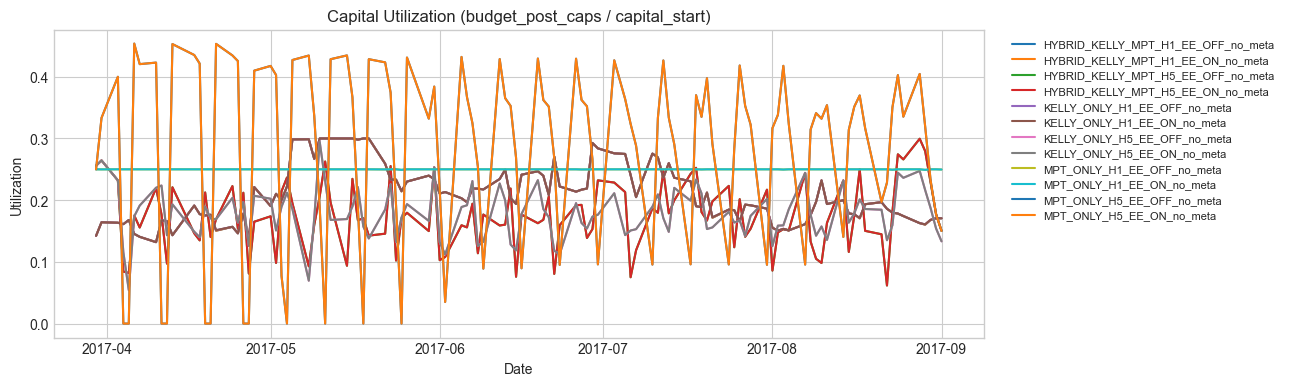

In [151]:
fig, ax = plt.subplots(figsize=(12, 4))
for mode, df in dfs.items():
    if {'budget_post_caps', 'capital_start'}.issubset(df.columns):
        utilization = df['budget_post_caps'] / df['capital_start']
        ax.plot(df['date'], utilization, label=mode)
ax.set_title('Capital Utilization (budget_post_caps / capital_start)')
ax.set_xlabel('Date')
ax.set_ylabel('Utilization')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


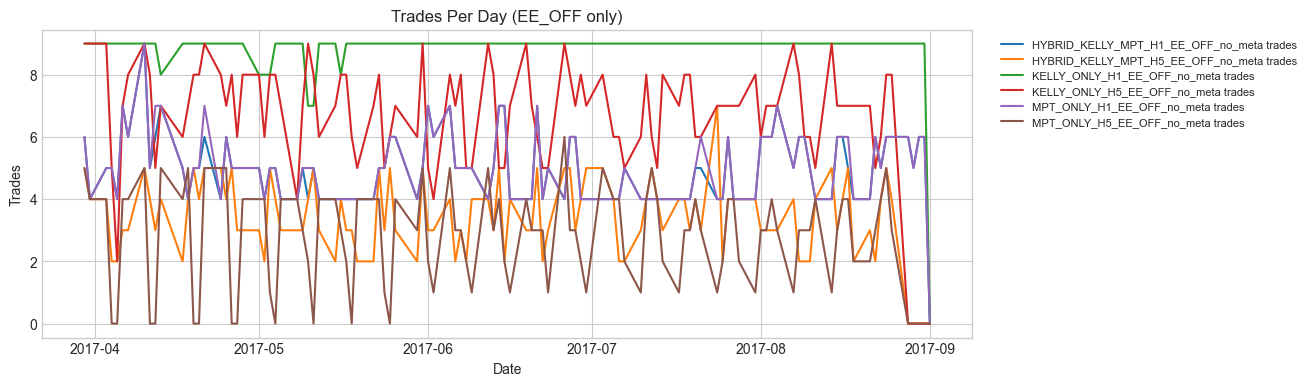

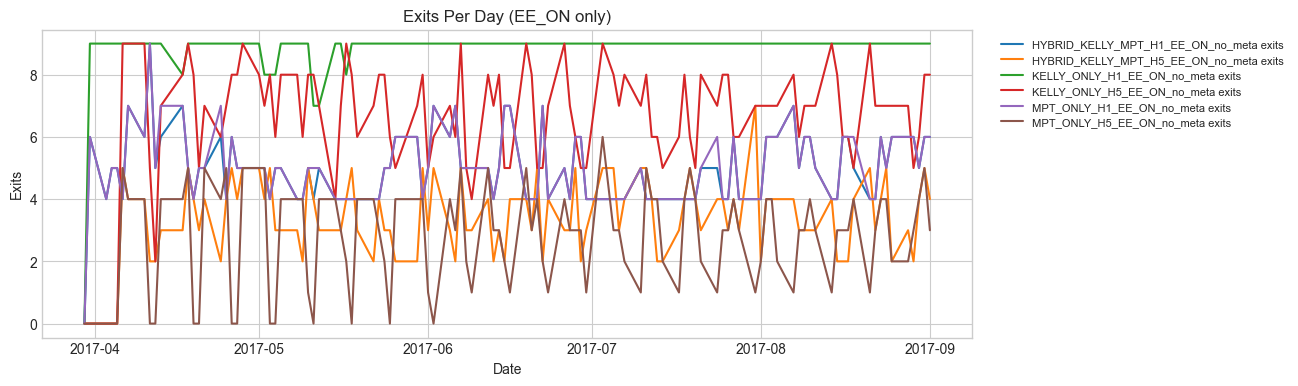

trades_made          exits     
                                          mean  sum      mean  sum
mode                                                              
HYBRID_KELLY_MPT_H1_EE_OFF_no_meta    4.954128  540  4.954128  540
HYBRID_KELLY_MPT_H1_EE_ON_no_meta     4.954128  540  4.954128  540
HYBRID_KELLY_MPT_H5_EE_OFF_no_meta    3.376147  368  3.376147  368
HYBRID_KELLY_MPT_H5_EE_ON_no_meta     3.376147  368  3.376147  368
KELLY_ONLY_H1_EE_OFF_no_meta          8.834862  963  8.834862  963
KELLY_ONLY_H1_EE_ON_no_meta           8.834862  963  8.834862  963
KELLY_ONLY_H5_EE_OFF_no_meta          6.614679  721  6.614679  721
KELLY_ONLY_H5_EE_ON_no_meta           6.614679  721  6.614679  721
MPT_ONLY_H1_EE_OFF_no_meta            5.000000  545  5.000000  545
MPT_ONLY_H1_EE_ON_no_meta             5.000000  545  5.000000  545
MPT_ONLY_H5_EE_OFF_no_meta            2.724771  297  2.724771  297
MPT_ONLY_H5_EE_ON_no_meta             2.724771  297  2.724771  297

In [152]:
trade_rows = []
for mode, df in dfs.items():
    if 'investments_made' in df.columns:
        inv = df['investments_made'].apply(_parse_maybe)
        trade_counts = inv.apply(lambda x: len(x) if isinstance(x, list) else 0)
    else:
        trade_counts = pd.Series(0, index=df.index)

    if 'exits_today' in df.columns:
        exits = df['exits_today'].apply(_parse_maybe)
        exit_counts = exits.apply(lambda x: len(x) if isinstance(x, list) else 0)
    else:
        exit_counts = pd.Series(0, index=df.index)

    trade_rows.append(pd.DataFrame({
        'date': df['date'],
        'mode': mode,
        'trades_made': trade_counts,
        'exits': exit_counts,
    }))

trades_df = pd.concat(trade_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 4))
for mode in trades_df['mode'].unique():
    df_mode = dfs.get(mode)
    if df_mode is not None and 'early_exit_enabled' in df_mode.columns:
        ee_on = bool(df_mode['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if ee_on:
        continue
    subset = trades_df[trades_df['mode'] == mode]
    ax.plot(subset['date'], subset['trades_made'], label=f'{mode} trades')
ax.set_title('Trades Per Day (EE_OFF only)')
ax.set_xlabel('Date')
ax.set_ylabel('Trades')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for mode in trades_df['mode'].unique():
    df_mode = dfs.get(mode)
    if df_mode is not None and 'early_exit_enabled' in df_mode.columns:
        ee_on = bool(df_mode['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if not ee_on:
        continue
    subset = trades_df[trades_df['mode'] == mode]
    ax.plot(subset['date'], subset['exits'], label=f'{mode} exits')
ax.set_title('Exits Per Day (EE_ON only)')
ax.set_xlabel('Date')
ax.set_ylabel('Exits')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

trades_summary = trades_df.groupby('mode')[['trades_made', 'exits']].agg(['mean', 'sum'])
trades_summary


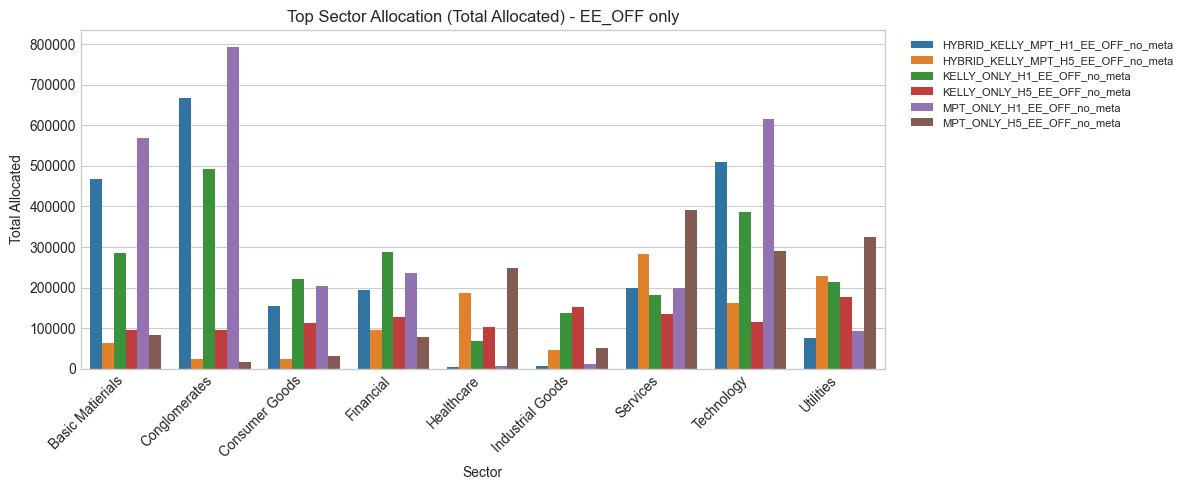

In [153]:
sector_rows = []
for mode, df in dfs.items():
    if 'investments_made' not in df.columns:
        continue
    if 'early_exit_enabled' in df.columns:
        ee_on = bool(df['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if ee_on:
        continue
    inv = df['investments_made'].apply(_parse_maybe)
    for day_list in inv:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if not isinstance(item, dict):
                continue
            sector = item.get('sector', 'UNKNOWN')
            allocated = item.get('allocated_amount', item.get('invest', np.nan))
            sector_rows.append({'mode': mode, 'sector': sector, 'allocated': allocated})

sector_df = pd.DataFrame(sector_rows)
if not sector_df.empty:
    sector_summary = sector_df.groupby(['mode', 'sector'])['allocated'].sum().reset_index()
    top_sectors = sector_summary.groupby('sector')['allocated'].sum().nlargest(12).index
    plot_df = sector_summary[sector_summary['sector'].isin(top_sectors)]

    plt.figure(figsize=(12, 5))
    if _HAS_SEABORN:
        sns.barplot(data=plot_df, x='sector', y='allocated', hue='mode')
    else:
        for mode in plot_df['mode'].unique():
            subset = plot_df[plot_df['mode'] == mode]
            plt.bar(subset['sector'], subset['allocated'], alpha=0.6, label=mode)
    plt.title('Top Sector Allocation (Total Allocated) - EE_OFF only')
    plt.xlabel('Sector')
    plt.ylabel('Total Allocated')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    sector_pivot = sector_summary.pivot(index='sector', columns='mode', values='allocated').fillna(0)
    sector_pivot


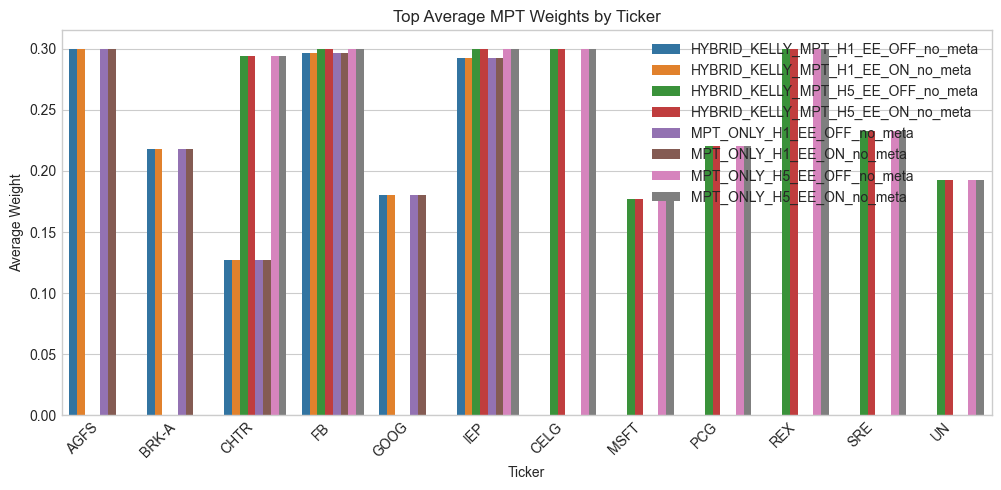

In [154]:
ticker_rows = []
for mode, df in dfs.items():
    if 'mpt_weights' not in df.columns:
        continue
    weights = df['mpt_weights'].apply(_parse_maybe)
    for weight_map in weights:
        if not isinstance(weight_map, dict):
            continue
        for ticker, w in weight_map.items():
            ticker_rows.append({'mode': mode, 'ticker': ticker, 'weight': float(w)})

ticker_df = pd.DataFrame(ticker_rows)
if not ticker_df.empty:
    ticker_summary = ticker_df.groupby(['mode', 'ticker'])['weight'].mean().reset_index()
    top_tickers = ticker_summary.groupby('ticker')['weight'].mean().nlargest(12).index
    plot_df = ticker_summary[ticker_summary['ticker'].isin(top_tickers)]

    plt.figure(figsize=(12, 5))
    if _HAS_SEABORN:
        sns.barplot(data=plot_df, x='ticker', y='weight', hue='mode')
    else:
        for mode in plot_df['mode'].unique():
            subset = plot_df[plot_df['mode'] == mode]
            plt.bar(subset['ticker'], subset['weight'], alpha=0.6, label=mode)
    plt.title('Top Average MPT Weights by Ticker')
    plt.xlabel('Ticker')
    plt.ylabel('Average Weight')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    ticker_pivot = ticker_summary.pivot(index='ticker', columns='mode', values='weight').fillna(0)
    ticker_pivot


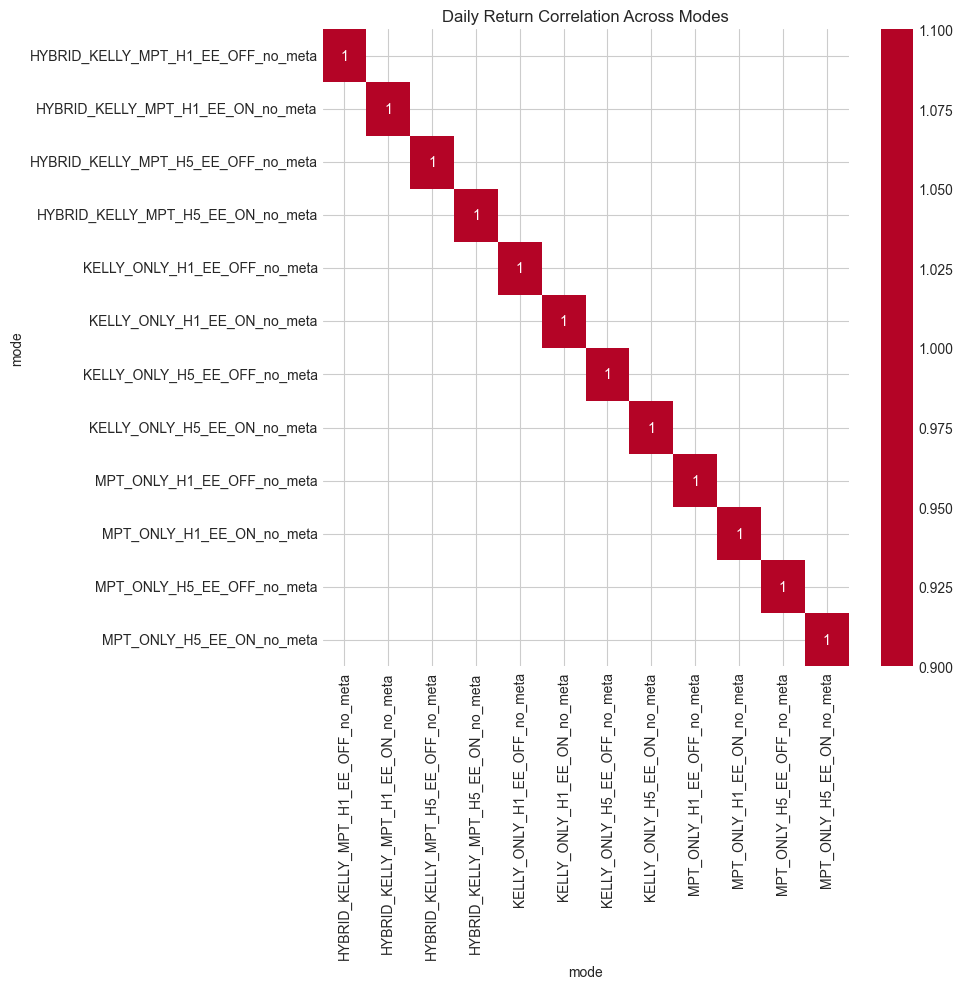

In [155]:
returns_pivot = returns_df.pivot(columns='mode', values='daily_return')
corr = returns_pivot.corr()

plt.figure(figsize=(10, 10))
if _HAS_SEABORN:
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
else:
    plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.index)), corr.index)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

plt.title('Daily Return Correlation Across Modes')
plt.tight_layout()
plt.show()


In [156]:
hyperparam_cols = [
    'H', 'initial_capital', 'initial_training_days', 'allow_overlap', 'seed', 'model_save_path',
    'min_sequence_length', 'max_sequence_length', 'kelly_fraction', 'sector_confidence_threshold',
    'retrain_interval', 'max_day_gap', 'mpt_window_days', 'mpt_lambda', 'mpt_ridge_eps',
    'mpt_max_weight', 'mpt_long_only', 'mpt_use_equal_fallback', 'mpt_only_budget_fraction',
    'max_total_utilization', 'max_new_daily_utilization', 'max_ticker_utilization',
    'max_sector_utilization', 'max_position_size', 'max_positions_per_ticker', 'min_trade_dollars',
    'kelly_trade_cap', 'drawdown_throttle_levels'
]

hyper_rows = []
for mode, df in dfs.items():
    row = {
        'mode': mode,
    }
    for col in hyperparam_cols:
        if col in df.columns:
            row[col] = df[col].iloc[0]
    hyper_rows.append(row)

hyper_df = pd.DataFrame(hyper_rows).set_index('mode')
hyper_df


,H,initial_capital,initial_training_days,allow_overlap,seed,model_save_path,min_sequence_length,max_sequence_length,kelly_fraction,sector_confidence_threshold,...,mpt_only_budget_fraction,max_total_utilization,max_new_daily_utilization,max_ticker_utilization,max_sector_utilization,max_position_size,max_positions_per_ticker,min_trade_dollars,kelly_trade_cap,drawdown_throttle_levels
mode,,,,,,,,,,,,,,,,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF_no_meta,1,100000.0,1100,True,42,/mnt/primary/simulation/trained_models,12,12,0.1,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
HYBRID_KELLY_MPT_H1_EE_ON_no_meta,1,100000.0,1100,True,42,/mnt/primary/simulation/trained_models,12,12,0.1,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
HYBRID_KELLY_MPT_H5_EE_OFF_no_meta,5,100000.0,1100,True,42,/mnt/primary/simulation/trained_models,12,12,0.1,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
HYBRID_KELLY_MPT_H5_EE_ON_no_meta,5,100000.0,1100,True,42,/mnt/primary/simulation/trained_models,12,12,0.1,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
KELLY_ONLY_H1_EE_OFF_no_meta,1,100000.0,1100,True,42,/mnt/primary/simulation/trained_models,12,12,0.1,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
KELLY_ONLY_H1_EE_ON_no_meta,1,100000.0,1100,True,42,/mnt/primary/simulation/trained_models,12,12,0.1,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
KELLY_ONLY_H5_EE_OFF_no_meta,5,100000.0,1100,True,42,/mnt/primary/simulation/trained_models,12,12,0.1,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
KELLY_ONLY_H5_EE_ON_no_meta,5,100000.0,1100,True,42,/mnt/primary/simulation/trained_models,12,12,0.1,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
MPT_ONLY_H1_EE_OFF_no_meta,1,100000.0,1100,True,42,/mnt/primary/simulation/trained_models,12,12,0.1,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"


In [157]:
# Summary table: trades, biggest winners/losers, average PnL, ROI, Sharpe
summary_rows = []

for mode, df in dfs.items():
    # Trade-level stats from exits_today
    exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
    exit_trades = []
    for day_list in exits_series:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if isinstance(item, dict):
                exit_trades.append(item)

    trades_df = pd.DataFrame(exit_trades)
    total_trades = len(trades_df)

    biggest_winner = np.nan
    biggest_loser = np.nan
    avg_pnl = np.nan
    if not trades_df.empty and 'pnl' in trades_df.columns:
        trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
        biggest_winner = trades_df['pnl'].max()
        biggest_loser = trades_df['pnl'].min()
        avg_pnl = trades_df['pnl'].mean()

    # ROI + Sharpe from equity curve
    metrics = _metrics_from_df(df)

    summary_rows.append({
        'mode': mode,
        'total_trades': total_trades,
        'biggest_winner_pnl': biggest_winner,
        'biggest_loser_pnl': biggest_loser,
        'avg_trade_pnl': avg_pnl,
        'total_return': metrics.get('total_return'),
        'sharpe': metrics.get('sharpe'),
    })

summary_table = pd.DataFrame(summary_rows).set_index('mode')
summary_table


,total_trades,biggest_winner_pnl,biggest_loser_pnl,avg_trade_pnl,total_return,sharpe
mode,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF_no_meta,540,457.297498,-397.747224,4.195895,0.022658,1.713014
HYBRID_KELLY_MPT_H1_EE_ON_no_meta,540,457.297498,-397.747224,4.195895,0.022658,1.713014
HYBRID_KELLY_MPT_H5_EE_OFF_no_meta,368,478.157054,-288.444686,21.603766,0.079502,6.285184
HYBRID_KELLY_MPT_H5_EE_ON_no_meta,368,478.157054,-288.444686,21.603766,0.079502,6.285184
KELLY_ONLY_H1_EE_OFF_no_meta,963,297.057302,-345.406625,1.425195,0.013725,1.336472
KELLY_ONLY_H1_EE_ON_no_meta,963,297.057302,-345.406625,1.425195,0.013725,1.336472
KELLY_ONLY_H5_EE_OFF_no_meta,721,219.465557,-106.911390,5.233625,0.037734,4.495150
KELLY_ONLY_H5_EE_ON_no_meta,721,219.465557,-106.911390,5.233625,0.037734,4.495150
MPT_ONLY_H1_EE_OFF_no_meta,545,514.057464,-601.886536,4.704398,0.025639,1.726539


In [158]:
# Additional tables: top tickers/sectors winners/losers and summaries
tables = {}

for mode, df in dfs.items():
    exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
    exit_trades = []
    for day_list in exits_series:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if isinstance(item, dict):
                exit_trades.append(item)

    trades_df = pd.DataFrame(exit_trades)
    if trades_df.empty:
        continue

    # Normalize fields
    if 'pnl' in trades_df.columns:
        trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
    if 'ticker' in trades_df.columns:
        trades_df['ticker'] = trades_df['ticker'].astype(str)
    if 'sector' in trades_df.columns:
        trades_df['sector'] = trades_df['sector'].astype(str)

    # Top/bottom trades overall
    if 'pnl' in trades_df.columns:
        tables[f'{mode} | Top 10 Trades (PnL)'] = trades_df.sort_values('pnl', ascending=False).head(10)
        tables[f'{mode} | Bottom 10 Trades (PnL)'] = trades_df.sort_values('pnl', ascending=True).head(10)

    # Ticker-level winners/losers
    if {'ticker', 'pnl'}.issubset(trades_df.columns):
        ticker_summary = trades_df.groupby('ticker')['pnl'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
        tables[f'{mode} | Top 10 Ticker Winners (Total PnL)'] = ticker_summary.head(10)
        tables[f'{mode} | Top 10 Ticker Losers (Total PnL)'] = ticker_summary.tail(10).sort_values('sum')

    # Sector-level winners/losers
    if {'sector', 'pnl'}.issubset(trades_df.columns):
        sector_summary = trades_df.groupby('sector')['pnl'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
        tables[f'{mode} | Top 10 Sector Winners (Total PnL)'] = sector_summary.head(10)
        tables[f'{mode} | Top 10 Sector Losers (Total PnL)'] = sector_summary.tail(10).sort_values('sum')

# Show all tables
tables



for name, table in tables.items():
    print(f"\n=== {name} ===")
    if isinstance(table, pd.DataFrame):
        display(table)
    else:
        display(pd.DataFrame(table))



=== HYBRID_KELLY_MPT_H1_EE_OFF_no_meta | Top 10 Trades (PnL) ===


,date,exit_date,ticker,sector,allocated_amount,prob_up,expected_rise,actual_return,pnl,exit_reason
129,2017-05-04 00:00:00,2017-05-05 00:00:00,AGFS,Conglomerates,6630.813716,0.700000,0.011513,0.068966,457.297498,scheduled
279,2017-06-16 00:00:00,2017-06-19 00:00:00,AGFS,Conglomerates,7283.135528,0.700000,0.011894,0.050704,369.285745,scheduled
402,2017-07-27 00:00:00,2017-07-28 00:00:00,AGFS,Conglomerates,5897.582869,0.700000,0.011571,0.040576,239.299828,scheduled
185,2017-05-23 00:00:00,2017-05-24 00:00:00,CHTR,Services,7001.672752,0.677886,0.005276,0.032153,225.123573,scheduled
397,2017-07-26 00:00:00,2017-07-27 00:00:00,VZ,Technology,2905.955085,0.628028,0.001948,0.076802,223.182511,scheduled
215,2017-06-01 00:00:00,2017-06-02 00:00:00,AGFS,Conglomerates,6366.431236,0.700000,0.011908,0.034965,222.602491,scheduled
309,2017-06-27 00:00:00,2017-06-28 00:00:00,BBL,Basic Matierials,6549.100573,0.714286,0.007130,0.033613,220.137834,scheduled
311,2017-06-27 00:00:00,2017-06-28 00:00:00,CHTR,Services,6549.100573,0.677886,0.005191,0.031618,207.072708,scheduled
206,2017-05-30 00:00:00,2017-05-31 00:00:00,AGFS,Conglomerates,7207.235976,0.700000,0.011910,0.027778,200.200999,scheduled
316,2017-06-28 00:00:00,2017-06-29 00:00:00,AGFS,Conglomerates,6641.161490,0.700000,0.011723,0.029577,196.428720,scheduled



=== HYBRID_KELLY_MPT_H1_EE_OFF_no_meta | Bottom 10 Trades (PnL) ===


,date,exit_date,ticker,sector,allocated_amount,prob_up,expected_rise,actual_return,pnl,exit_reason
396,2017-07-26 00:00:00,2017-07-27 00:00:00,AGFS,Conglomerates,5072.806900,0.700000,0.011591,-0.078408,-397.747224,scheduled
287,2017-06-20 00:00:00,2017-06-21 00:00:00,AGFS,Conglomerates,7244.319857,0.700000,0.011900,-0.052632,-381.279992,scheduled
240,2017-06-07 00:00:00,2017-06-08 00:00:00,AGFS,Conglomerates,6622.315636,0.700000,0.011902,-0.049202,-325.832019,scheduled
164,2017-05-16 00:00:00,2017-05-17 00:00:00,FB,Technology,9318.305765,0.698476,0.006459,-0.032915,-306.711060,scheduled
420,2017-08-02 00:00:00,2017-08-03 00:00:00,AGFS,Conglomerates,4622.217107,0.700000,0.011503,-0.059045,-272.919854,scheduled
282,2017-06-19 00:00:00,2017-06-20 00:00:00,BBL,Basic Matierials,7492.312306,0.714286,0.007190,-0.034368,-257.493058,scheduled
392,2017-07-25 00:00:00,2017-07-26 00:00:00,AGFS,Conglomerates,5643.447561,0.700000,0.011570,-0.042725,-241.117275,scheduled
120,2017-05-02 00:00:00,2017-05-03 00:00:00,AGFS,Conglomerates,6320.077599,0.700000,0.011516,-0.033929,-214.431204,scheduled
124,2017-05-03 00:00:00,2017-05-04 00:00:00,AGFS,Conglomerates,5979.807307,0.700000,0.011525,-0.035120,-210.011717,scheduled
163,2017-05-16 00:00:00,2017-05-17 00:00:00,HRG,Conglomerates,9318.305765,1.000000,0.012420,-0.020270,-188.884576,scheduled



=== HYBRID_KELLY_MPT_H1_EE_OFF_no_meta | Top 10 Ticker Winners (Total PnL) ===


...

,sum,mean,count
ticker,,,
CELG,-500.891748,-16.696392,30
GE,-373.588269,-21.975781,17
BBL,-116.299229,-19.383205,6
PG,-17.024963,-17.024963,1
HRG,-15.519878,-3.103976,5
GD,21.560961,5.390240,4
V,23.028117,11.514058,2
REX,44.628940,44.628940,1
HD,66.182358,4.727311,14



=== MPT_ONLY_H5_EE_ON_no_meta | Top 10 Sector Winners (Total PnL) ===


,sum,mean,count
sector,,,
Services,3760.036791,58.750575,64
Utilities,1792.343431,33.817801,53
Technology,1657.648739,29.600870,56
Basic Matierials,769.668142,32.069506,24
Healthcare,762.703185,20.613600,37
Consumer Goods,365.983575,73.196715,5
Financial,297.241220,13.510965,22
Conglomerates,29.109062,4.851510,6
Industrial Goods,-271.978740,-9.065958,30



=== MPT_ONLY_H5_EE_ON_no_meta | Top 10 Sector Losers (Total PnL) ===


,sum,mean,count
sector,,,
Industrial Goods,-271.978740,-9.065958,30
Conglomerates,29.109062,4.851510,6
Financial,297.241220,13.510965,22
Consumer Goods,365.983575,73.196715,5
Healthcare,762.703185,20.613600,37
Basic Matierials,769.668142,32.069506,24
Technology,1657.648739,29.600870,56
Utilities,1792.343431,33.817801,53
Services,3760.036791,58.750575,64


In [159]:
# ROI table (Total Return %)
roi_rows = []
for mode, df in dfs.items():
    metrics = _metrics_from_df(df)
    roi_rows.append({
        'mode': mode,
        'total_return': metrics.get('total_return'),
        'total_return_pct': (metrics.get('total_return') or np.nan) * 100.0,
        'CAGR': metrics.get('CAGR'),
    })

roi_table = pd.DataFrame(roi_rows).set_index('mode').sort_values('total_return', ascending=False)
roi_table


,total_return,total_return_pct,CAGR
mode,,,
MPT_ONLY_H5_EE_OFF_no_meta,0.091628,9.162755,0.224688
MPT_ONLY_H5_EE_ON_no_meta,0.091628,9.162755,0.224688
HYBRID_KELLY_MPT_H5_EE_OFF_no_meta,0.079502,7.950186,0.193466
HYBRID_KELLY_MPT_H5_EE_ON_no_meta,0.079502,7.950186,0.193466
KELLY_ONLY_H5_EE_OFF_no_meta,0.037734,3.773443,0.089407
KELLY_ONLY_H5_EE_ON_no_meta,0.037734,3.773443,0.089407
MPT_ONLY_H1_EE_OFF_no_meta,0.025639,2.563897,0.060275
MPT_ONLY_H1_EE_ON_no_meta,0.025639,2.563897,0.060275
HYBRID_KELLY_MPT_H1_EE_OFF_no_meta,0.022658,2.265783,0.053164


In [160]:
# Combined table: ROI, Sharpe, avg trade size, avg trade PnL + hyperparameters
rows = []

for mode, df in dfs.items():
    metrics = _metrics_from_df(df)

    exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
    exit_trades = []
    for day_list in exits_series:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if isinstance(item, dict):
                exit_trades.append(item)

    trades_df = pd.DataFrame(exit_trades)
    avg_trade_size = np.nan
    avg_trade_pnl = np.nan
    if not trades_df.empty:
        if 'allocated_amount' in trades_df.columns:
            trades_df['allocated_amount'] = pd.to_numeric(trades_df['allocated_amount'], errors='coerce')
            avg_trade_size = trades_df['allocated_amount'].mean()
        if 'pnl' in trades_df.columns:
            trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
            avg_trade_pnl = trades_df['pnl'].mean()

    row = {
        'mode': mode,
        'ROI': metrics.get('total_return'),
        'ROI_pct': (metrics.get('total_return') or np.nan) * 100.0,
        'Sharpe': metrics.get('sharpe'),
        'Avg_Trade_Size': avg_trade_size,
        'Avg_Trade_PnL': avg_trade_pnl,
    }

    # Attach hyperparameters
    if 'hyper_df' in globals():
        if mode in hyper_df.index:
            for col in hyper_df.columns:
                row[col] = hyper_df.loc[mode, col]
    else:
        # fallback: use first row from df if hyper_df not available
        for col in hyperparam_cols if 'hyperparam_cols' in globals() else []:
            if col in df.columns:
                row[col] = df[col].iloc[0]

    rows.append(row)

combined_table = pd.DataFrame(rows).set_index('mode')
combined_table


,ROI,ROI_pct,Sharpe,Avg_Trade_Size,Avg_Trade_PnL,H,initial_capital,initial_training_days,allow_overlap,seed,...,mpt_only_budget_fraction,max_total_utilization,max_new_daily_utilization,max_ticker_utilization,max_sector_utilization,max_position_size,max_positions_per_ticker,min_trade_dollars,kelly_trade_cap,drawdown_throttle_levels
mode,,,,,,,,,,,,,,,,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF_no_meta,0.022658,2.265783,1.713014,4219.673746,4.195895,1,100000.0,1100,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
HYBRID_KELLY_MPT_H1_EE_ON_no_meta,0.022658,2.265783,1.713014,4219.673746,4.195895,1,100000.0,1100,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
HYBRID_KELLY_MPT_H5_EE_OFF_no_meta,0.079502,7.950186,6.285184,3024.240181,21.603766,5,100000.0,1100,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
HYBRID_KELLY_MPT_H5_EE_ON_no_meta,0.079502,7.950186,6.285184,3024.240181,21.603766,5,100000.0,1100,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
KELLY_ONLY_H1_EE_OFF_no_meta,0.013725,1.372463,1.336472,2359.501788,1.425195,1,100000.0,1100,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
KELLY_ONLY_H1_EE_ON_no_meta,0.013725,1.372463,1.336472,2359.501788,1.425195,1,100000.0,1100,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
KELLY_ONLY_H5_EE_OFF_no_meta,0.037734,3.773443,4.495150,1548.277642,5.233625,5,100000.0,1100,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
KELLY_ONLY_H5_EE_ON_no_meta,0.037734,3.773443,4.495150,1548.277642,5.233625,5,100000.0,1100,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
MPT_ONLY_H1_EE_OFF_no_meta,0.025639,2.563897,1.726539,5005.325282,4.704398,1,100000.0,1100,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.05, 0.5], [0.1, 0.25]]"
